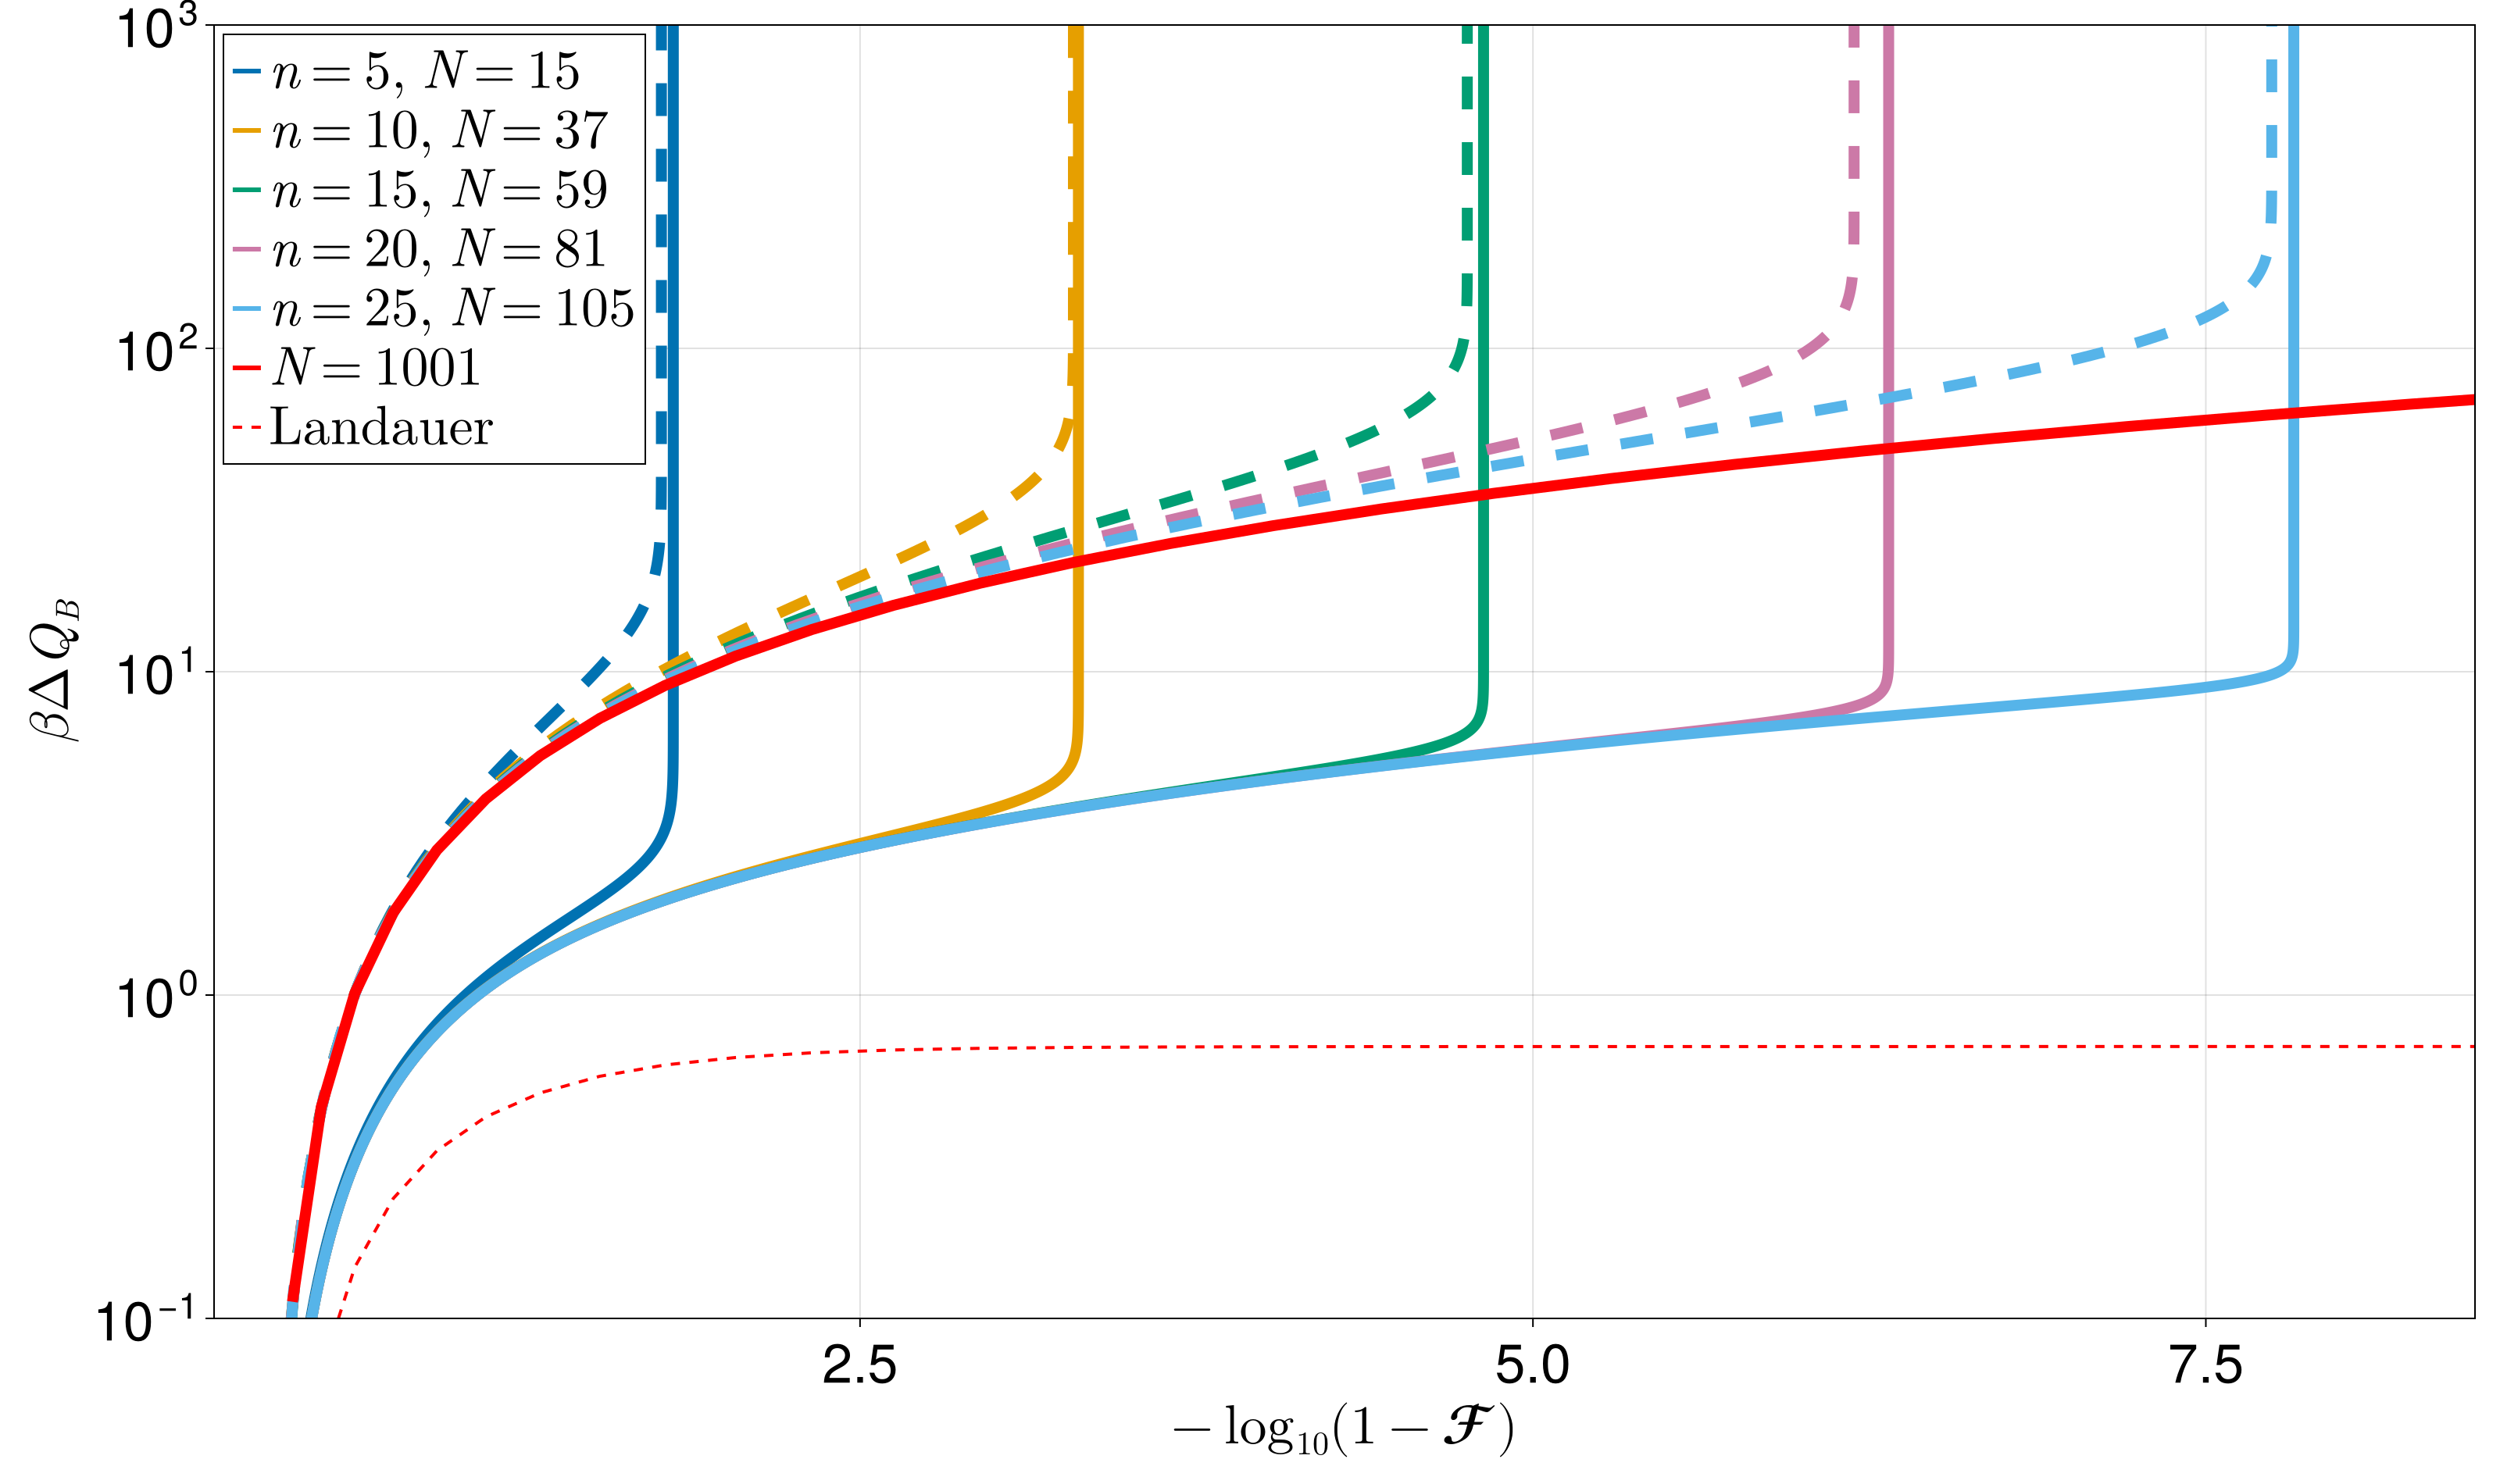

In [3]:
using CairoMakie
using LaTeXStrings
using Distributions
using SpecialFunctions


const kb = 1.380649e-23
const hbar = 1.054571817e-34
const p0  = 1/2
const ω   = hbar*2π*5*10^9
const β   = 1/(kb*0.1)
const g   = 1.0
const βw  = 0
const ΔQ = ω*10^3*2
const ΔC = ω*100


# Core functions
w0V(Δ; ω=ω, βw=βw) = 1 / (1 + exp(-βw * (Δ - ω)))
w1V(Δ; ω=ω, βw=βw) = exp(-βw * (Δ - ω)) / (1 + exp(-βw * (Δ - ω)))

function p0n(n, Δ; p0=p0, β=β, βw=βw, ω=ω)
    A = exp(β * Δ)
    w0 = w0V(Δ; ω=ω, βw=βw)
    w1 = w1V(Δ; ω=ω, βw=βw)
    ZB = 1 + exp(-β * Δ)
    return (1- (1- w1*(1+w0/w1* exp(-β * Δ))/ZB)^n )/(1 + w0/w1*exp(-β * Δ)) + p0*(1- w1*(1+w0/w1* exp(-β * Δ))/ZB)^n
end

# With βw = 0 and p0 = 1/2 this is simply 1 - 2^(-(n+1))
divpoint(n; p0=p0, βw=βw, ω=ω) = 1 - (1 - p0) * (1 - w1V(0.0; ω=ω, βw=βw))^n

Totlines = 6 - 1
scalingQ(n) = 5n + 5

DivergencePoint = [divpoint(scalingQ(n)) for n in 0:Totlines-1]

# log-distance to F = 1
xF(F) = -log10(1 - F)
logF(x) = -log10(1 - x)


basecolors = Makie.wong_colors()
colors = [basecolors[mod1(i, length(basecolors))] for i in 1:Totlines]

p0C(Δ) = p0n(1, Δ)

function Fid(n, Δ)
    p = 1 - p0C(Δ)
    return cdf(Binomial(n, p), floor(Int, n / 2))
end

function directscaling(n)
    w1 = w1V(1; ω=ω, βw=βw)
    n = scalingQ(n)
    return (2n * log(1 - w1)) / log(1 - w1^2) + log(n)/ log(1 - w1^2)  + log(log(1-w1)/log(1 - w1^2))/ log(1 - w1^2)
end

function scaling(n)
    f = floor(Int, directscaling(n))
    return isodd(f) ? f : f - 1
end


# ---------- combined figure ----------
fig = Figure(size=(1600, 950))
ax = Axis(
    fig[1, 1],
    xlabelsize = 35,
    ylabelsize = 35,
    xlabel = L"-\log_{10}(1-\mathcal{F})",
    ylabel = L"\beta \Delta Q_B",
    #limits = (0.1, 8.5, 0.5, 300),
    limits = (0.1, 8.5, 10^-1, 10^3),
    xgridvisible = true,
    ygridvisible = true,
    xticklabelsize = 35,
    yticklabelsize = 35,
    yscale = log10,
)

lw = 7

#Δgrid = range(0, 1000, length=5000)
Δgrid = range(0, ΔQ, length=10^6)
for n in 0:Totlines-1
    N = scalingQ(n)
    ys = [Δ * (p0n(N, Δ) - p0) for Δ in Δgrid]
    xs = [xF(p0n(N, Δ)) for Δ in Δgrid]
    valid = isfinite.(xs) .& isfinite.(ys)
    xs = xs[valid]
    ys = ys[valid]
    lines!(ax, xs, β*ys, color=colors[n+1], linewidth=lw, linestyle=:solid)
end


Δgrid = range(0, 2*ΔC, length=10000)
for n in 0:Totlines-1
    N = scaling(n)
    ys = [N * Δ * (p0n(1, Δ) - p0) for Δ in Δgrid]
    xs = [logF(Fid(N, Δ)) for Δ in Δgrid]
    valid = isfinite.(xs) .& isfinite.(ys)
    xs = xs[valid]
    ys = ys[valid]
    lines!(ax, xs, β*ys, color=colors[n+1], linestyle=:dash, linewidth=lw)
end


NC = 10^3+1
Δgrid = range(0, 4, length=8000)
Δgrid = range(0, ΔC, length=8000)
xs3 = [logF(Fid(NC, Δ)) for Δ in Δgrid]
ys3 = [NC * Δ * (p0n(1, Δ) - p0) for Δ in Δgrid]
valid3 = isfinite.(xs3) .& isfinite.(ys3)
lines!(ax, xs3[valid3],β*ys3[valid3], color=:red, linewidth=lw, linestyle=:solid)




LandauerBound(ϵ) = log(2)+(1-ϵ)*log(1-ϵ)+ϵ*log(ϵ)
points_landauer = [Fid(NC, Δ) for Δ in Δgrid]
lines!(ax, logF.(points_landauer), LandauerBound.(points_landauer), color=:red, linestyle =:dash, linewidth=2, label=L"\text{Landauer Bound}")

legend1 = [L"n = %$(scalingQ(i)), \; N = %$(scaling(i))" for i in 0:Totlines-1]
legend2 = [L"N =  %$NC"]
legend3 = [L"\text{Landauer}"]
legendLabels = vcat(legend1, legend2, legend3)
legendElements = vcat(
    [LineElement(color=colors[i], linewidth=3) for i in 1:Totlines],
    [LineElement(color=:red, linewidth=3)],
    [LineElement(color=:red, linewidth=2, linestyle=:dash)]
)
axislegend(ax, legendElements, legendLabels, labelsize=35, position=:lt, framevisible=true, patchsize=(18, 10), tellheight=false, tellwidth=false)
Makie.save("Divergent_dissipation_figure.pdf", fig)
fig

## Plot of ticks

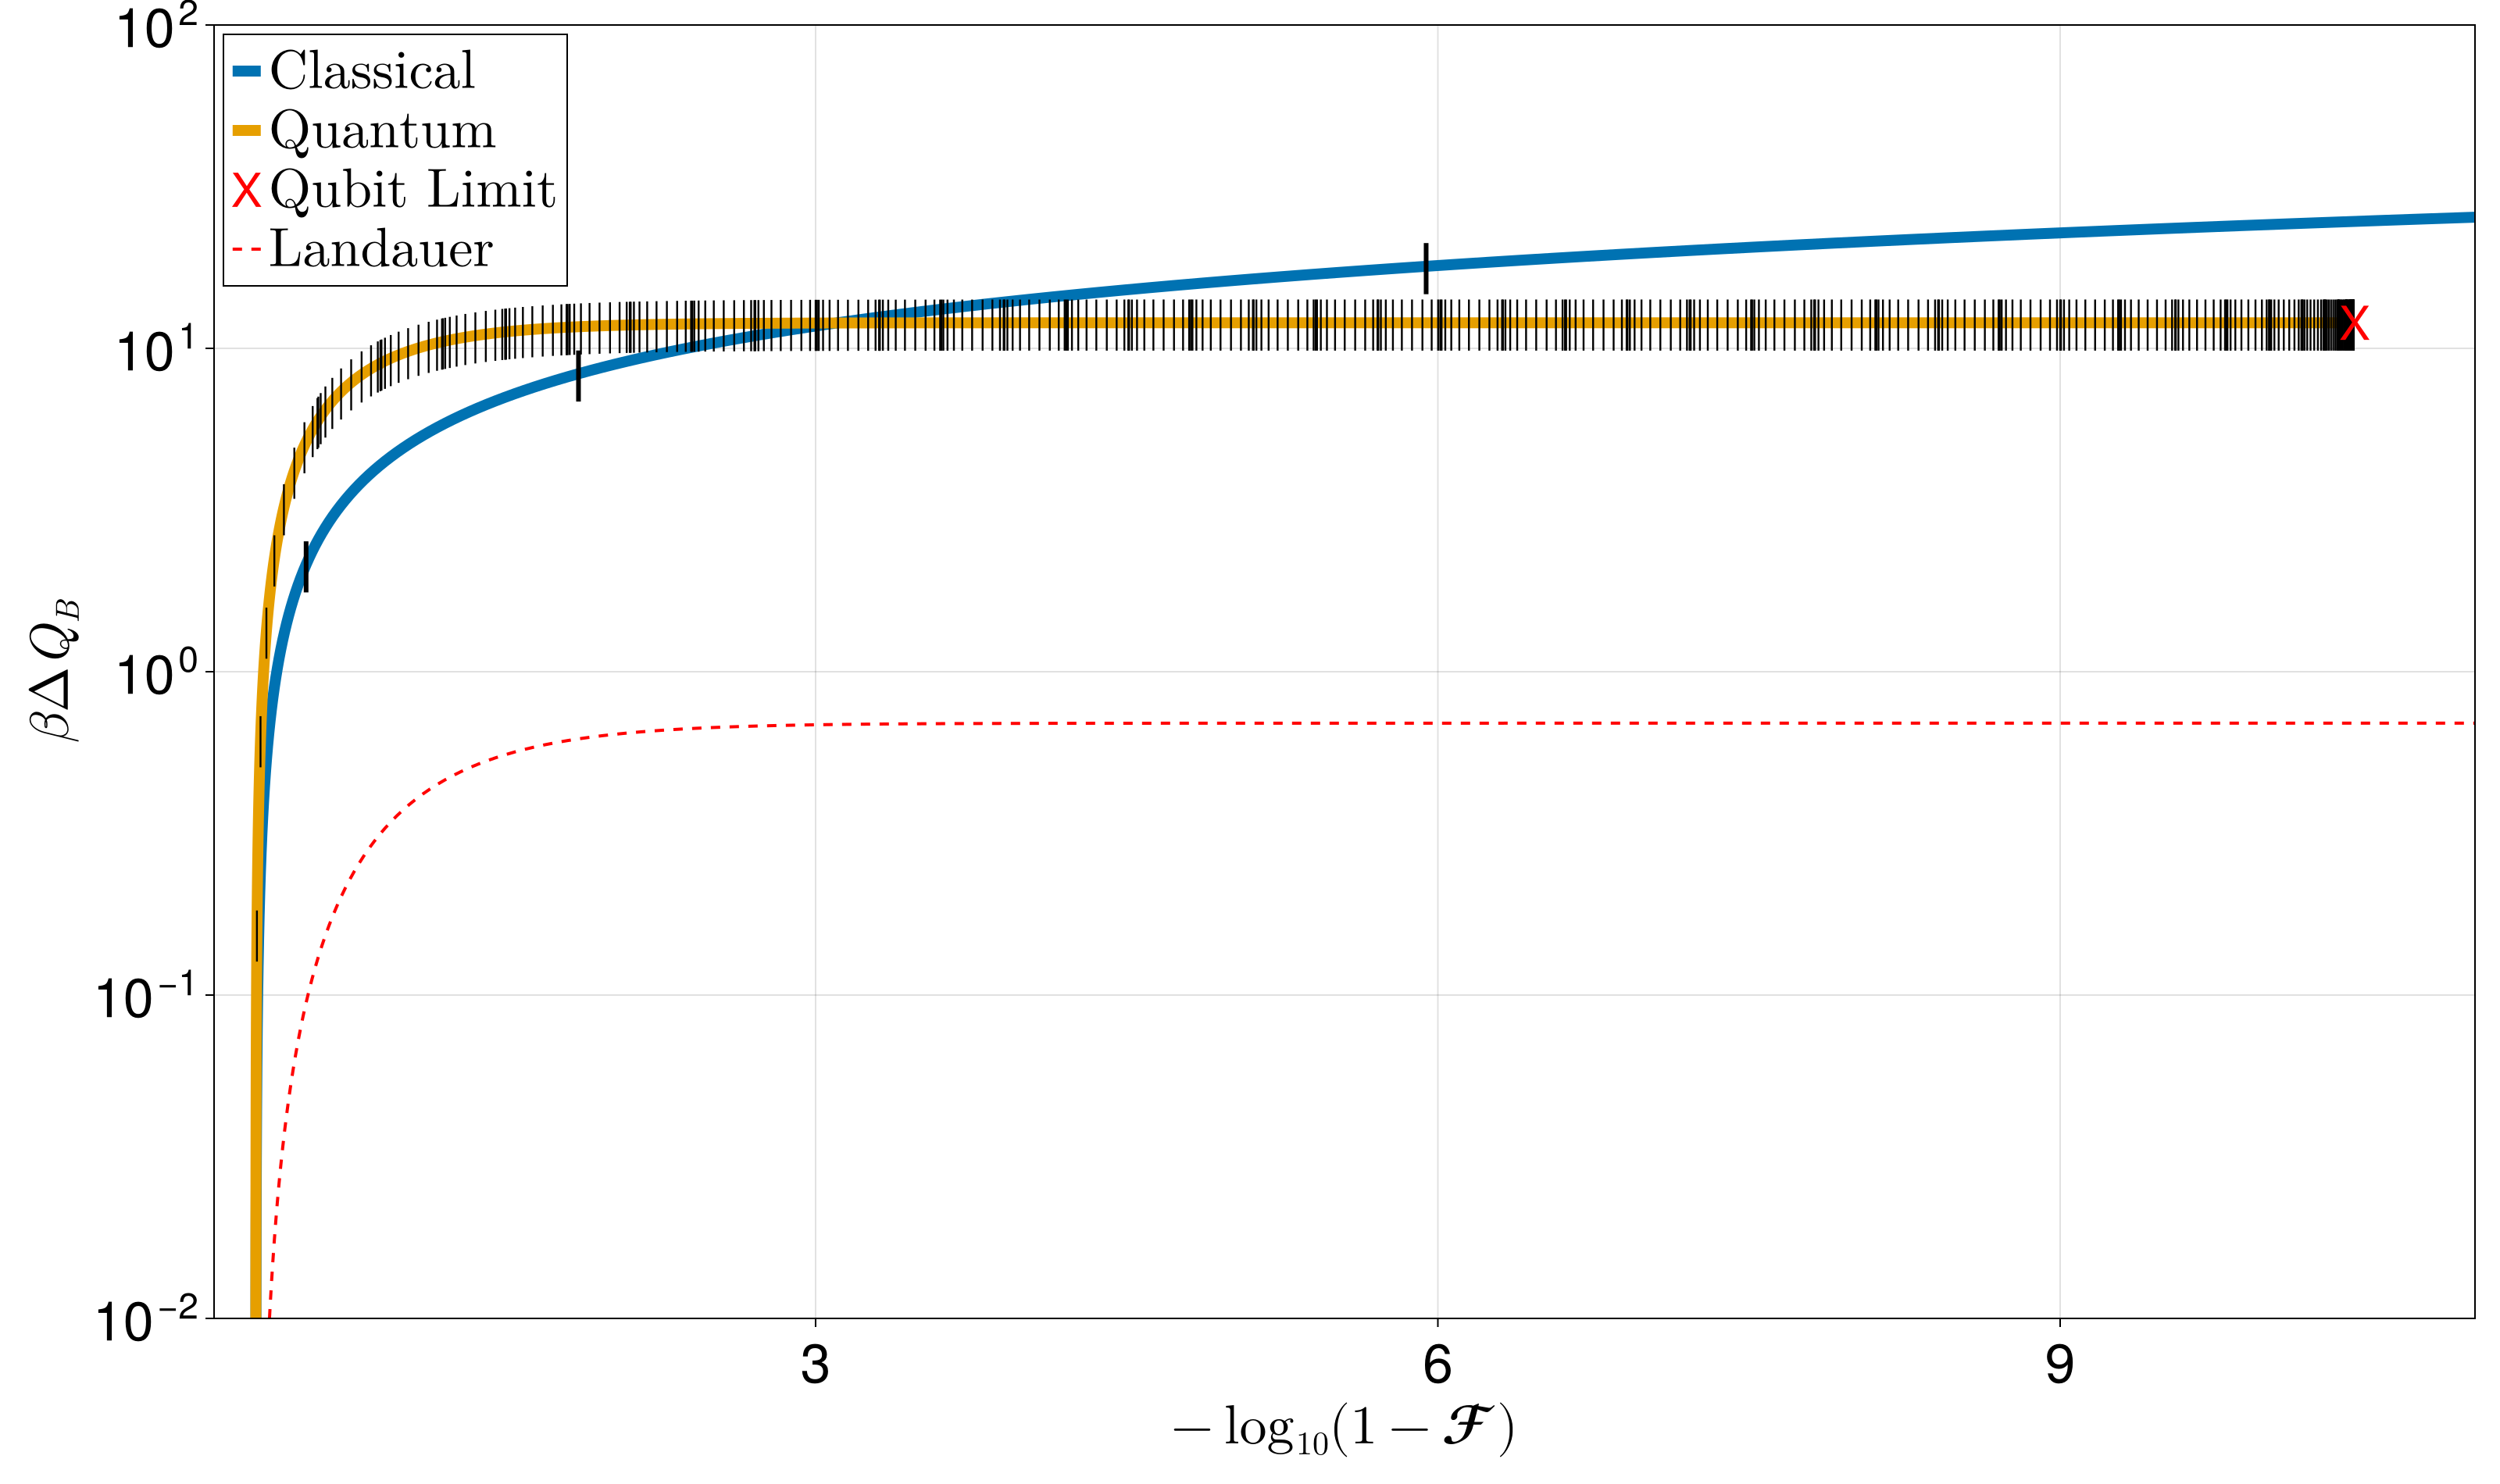

In [4]:
const N = 10^11+1
const βw  = 1/(kb*10^3)
const ΔQ = ω*10
const ΔC = ω*10^-5



function p0nt(p0, τ, Δ, ω)
    numerator1 = p0 * (
        exp((β + βw) * Δ) + exp(βw * ω) + (exp(βw * Δ) + exp(β * Δ + βw * ω)) * cos(g * τ)^2
    )

    numerator2 = exp(β * Δ + βw * ω) * sin(g * τ)^2

    denominator = (1 + exp(β * Δ)) * (exp(βw * Δ) + exp(βw * ω))

    return numerator1 / denominator + numerator2 / denominator
end


FidQ(p,τ) = p0nt(p, τ, ΔQ, ω)

p0C(τ) = p0nt(1/2, τ, ΔC, ω)

function Fid(τ)
    p = 1 - p0C(τ)
    return cdf(Binomial(N, p), floor(Int, N / 2))
end

dissipationClassical(τ) = N * ΔC * (p0nt(1/2, τ, ΔC, ω) - 1/2)

tlist = range(0, π/(2g), length=400)
FClist = [Fid(τ) for τ in tlist]
Cdissipationlist =abs.( [dissipationClassical(τ) for τ in tlist])

tlist = range(0, π/(2g), length=400)
swaps = 40
FQlist = [1/2]
for i in 1:swaps
    FQ(τ) = FidQ(FQlist[end], τ)
    push!(FQlist, FQ.(tlist)...) 
end
Qdissipationlist =abs.(ΔQ.*(FQlist .- 1/2));



fig = Figure(size=(1600, 950))
ax = Axis(
    fig[1, 1],
    xlabelsize = 35,
    ylabelsize = 35,
    xlabel = L"-\log_{10}(1-\mathcal{F})",
    #xlabel = L"\mathcal{F}",
    ylabel = L"\beta\Delta Q_B", 
    limits = (0.1, 11, 10^-2, 10^2),
    xgridvisible = true,
    ygridvisible = true,
    xticklabelsize = 35,
    yticklabelsize = 35,
    yscale = log10,
)

function add_time_gradient!(ax, xs, ys, ts, label; basecolor=:black, basewidth= 1 , innerwidth=3, colormap=:nipy_spectral, colorrange=nothing)
    points = isfinite.(xs) .& isfinite.(ys) .& isfinite.(ts)
    xs = xs[points]
    ys = ys[points]
    ts = ts[points]
    lines!(ax, xs, ys, color=basecolor, linewidth=basewidth,  label = label, alpha = 1)#,linecap=:round)
    #return lines!(ax, xs, ys, color=ts, colormap=colormap, colorrange=colorrange, linewidth=innerwidth)#, linecap=:round)
end

#stride = 50
stride = 42
function add_black_ticks!(ax, xs, ys; stride=stride, color=:grey, linewidth=0.7, scale=0.18, alpha = 0.5)
    points = isfinite.(xs) .& isfinite.(ys)
    xs = xs[points]
    ys = ys[points]
    tick_points = Point2f[]
    for idx in 1:stride:length(xs)
        x = xs[idx]
        y = ys[idx]
        if y > 0
            push!(tick_points, Point2f(x, y * (1 - scale)))
            push!(tick_points, Point2f(x, y * (1 + scale)))
        end
    end
    if !isempty(tick_points)
        linesegments!(ax, tick_points, color=color, linewidth=linewidth, alpha = alpha)#,linecap=:round, alpha = alpha)
    end
end

lw = 7
inlw = 7
tauopt = π / (2g)

qtimes = collect(range(0, swaps * tauopt, length=length(FQlist))) ./ tauopt
ctimes = collect(range(0, tauopt, length=length(FClist))) ./ tauopt

cgrad = add_time_gradient!(ax, logF.(FClist), β * Cdissipationlist, ctimes, L"\text{Classical}"; basecolor=colors[1], basewidth=lw, innerwidth=inlw, colorrange=(0, swaps))
qgrad = add_time_gradient!(ax, logF.(FQlist), β * Qdissipationlist, qtimes, L"\text{Quantum}"; basecolor=colors[2], basewidth=lw, innerwidth=inlw, colorrange=(0, swaps))

add_black_ticks!(ax, logF.(FClist),β * Cdissipationlist, color = :black, alpha = 1,linewidth= 3.0)
add_black_ticks!(ax, logF.(FQlist), β * Qdissipationlist, color = :black, alpha = 1,linewidth=1.2)#alpha = 0.5)

thermalizedFidQ = 1/(1+ exp(βw * (ΔQ - ω))*exp(-β * ΔQ))
scatter!(ax, logF(thermalizedFidQ),β * ΔQ*(thermalizedFidQ - 1/2), color=:red, markersize=30, marker='X', label=L"\text{Qubit Limit}")
#hlines!(ax, log(2), color=:red, linestyle =:dash, linewidth=2, label=L"\text{Landauer Bound}")


LandauerBound(ϵ) = log(2)+(1-ϵ)*log(1-ϵ)+ϵ*log(ϵ)
lines!(ax, logF.(FClist), LandauerBound.(1 .-FClist), color=:red, linestyle =:dash, linewidth=2, label=L"\text{Landauer}")

axislegend(ax, position=:lt, framevisible=true, patchsize=(18, 10), tellheight=false, tellwidth=false, labelsize=35)

Makie.save("dissipation_Time.pdf", fig)
fig